# Semana 3 – Modelado Inicial: Clustering a Nivel Macro
**CC3074 – Minería de Datos | Semestre I, 2026**

**Dataset:** `data_final_internet.csv`  
**Pregunta:** ¿Qué grupos de países latinoamericanos tienen trayectorias similares de adopción total de Internet entre 2000 y 2024?

---

### Estrategia del notebook
El dataset macro tiene **14 observaciones** (una por país). Un split train/test convencional con N=14 no es estadísticamente válido, por lo que:
- Se trabaja con el dataset completo (14 países)
- La validación usa **métricas internas** (Silhouette, Calinski-Harabasz, Davies-Bouldin)
- Se aplica **análisis de estabilidad por bootstrap** (submuestreo sin remplazo)

**Modelos comparados:**
1. K-Means++
2. Clustering Jerárquico – Ward
3. Clustering Jerárquico – Complete Linkage
4. Gaussian Mixture Model (GMM – covarianza tied)
5. K-Medoids (PAM)


## 1. Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

SEED = 42
PALETTE = ['#C084FC', '#F472B6', '#60A5FA', '#34D399', '#FBBF24']
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Carga y preprocesamiento

In [2]:
df = pd.read_csv('data_final_internet.csv')
print(f'Dimensiones: {df.shape}')
print(f'Países: {df["country"].tolist()}')
df

Dimensiones: (14, 26)
Países: ['Argentina', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Honduras', 'México', 'Panamá', 'Paraguay', 'Perú', 'Uruguay']


,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Argentina,9.147071,9.100000,10.000000,11.000000,12.100000,13.300000,14.60,16.000000,17.600000,...,62.0,71.000000,74.000000,78.000000,80.000000,86.000000,87.000000,89.000000,93.380004,93.692484
1,Bolivia (Estado Plurinacional de),1.000000,5.736992,1.785000,1.901714,2.000000,3.500000,3.30,3.300000,3.300000,...,38.0,39.000000,36.000000,44.000000,48.000000,60.000000,66.000000,62.625139,66.658890,68.732180
2,Brasil,10.325101,8.600000,10.300000,11.500000,12.400000,21.000000,16.82,20.000000,35.000000,...,58.0,53.907454,60.753979,66.662982,71.388171,83.169067,81.529378,80.235507,84.106092,83.436800
3,Chile,19.000000,9.600000,10.188493,28.000000,14.499313,16.684928,37.00,22.094192,26.600000,...,68.0,79.297795,75.000000,88.711802,89.900322,89.757834,93.796112,93.176312,94.346611,96.500377
4,Colombia,1.000000,4.500000,5.000000,5.460000,6.000000,6.200000,7.10,10.210000,12.800000,...,56.0,58.000000,49.952234,64.000000,65.000000,70.000000,73.000000,73.000000,63.935715,65.648787
5,Costa Rica,4.000000,5.350000,7.270000,10.010000,10.105000,10.202027,9.70,11.700000,14.821903,...,60.0,66.000000,72.000000,74.000000,81.000000,81.000000,83.000000,83.000000,81.739616,81.080338
6,Ecuador,1.000000,7.607684,2.033246,2.567592,2.770000,3.500000,4.37,6.830000,7.060000,...,51.0,56.000000,58.000000,56.000000,59.000000,53.209497,56.707103,60.434616,62.218931,65.975486
7,El Salvador,1.000000,1.000000,2.300000,2.400000,2.000000,2.100000,5.00,7.000000,4.532773,...,27.0,28.000000,34.000000,41.000000,51.000000,27.619048,31.236390,30.378243,31.675062,33.626441
8,Honduras,1.000000,4.270138,0.000000,1.100000,6.000000,7.000000,1.40,2.500000,4.152055,...,27.0,30.000000,26.481488,37.000000,40.000000,33.985537,45.641021,49.175139,50.830340,50.757290
9,México,1.000000,6.100000,7.500000,8.100000,8.700000,8.900000,10.10,12.004535,13.504304,...,57.0,60.000000,64.000000,64.000000,70.000000,73.000000,76.000000,79.000000,71.653521,73.605457


### 2.1 Ingeniería de features

In [3]:
YEAR_COLS = [c for c in df.columns if c != 'country']
YEARS     = np.array([int(y) for y in YEAR_COLS])
countries = df['country'].values
X_raw     = df[YEAR_COLS].values.astype(float)  # (14, 25)

# Features derivadas para interpretación
df_feat = pd.DataFrame({'country': countries})
df_feat['media_adopcion']    = X_raw.mean(axis=1).round(2)
df_feat['adopcion_2024']     = X_raw[:, -1].round(2)
df_feat['adopcion_2000']     = X_raw[:,  0].round(2)
df_feat['crecimiento_total'] = (X_raw[:, -1] - X_raw[:, 0]).round(2)
df_feat['pendiente']         = [round(np.polyfit(YEARS - YEARS.mean(), X_raw[i], 1)[0], 3)
                                for i in range(len(X_raw))]

print('Features derivadas:')
display(df_feat.set_index('country'))

Features derivadas:


,media_adopcion,adopcion_2024,adopcion_2000,crecimiento_total,pendiente
country,,,,,
Argentina,47.04,93.69,9.15,84.55,4.239
Bolivia (Estado Plurinacional de),28.25,68.73,1.00,67.73,3.158
Brasil,45.49,83.44,10.33,73.11,3.568
Chile,53.88,96.50,19.00,77.50,4.086
Colombia,36.34,65.65,1.00,64.65,3.524
Costa Rica,42.94,81.08,4.00,77.08,4.104
Ecuador,31.28,65.98,1.00,64.98,3.164
El Salvador,18.86,33.63,1.00,32.63,1.797
Honduras,20.45,50.76,1.00,49.76,2.284


### 2.2 Normalización

Se normaliza con `StandardScaler` para que ningún año domine por escala. Con N=14 se usa el dataset completo (no hay split train/test).

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Shape: {X_scaled.shape} | Media ≈ {X_scaled.mean():.4f} | Std ≈ {X_scaled.std():.4f}')

Shape: (14, 25) | Media ≈ 0.0000 | Std ≈ 1.0000


## 3. Selección del número óptimo de clusters

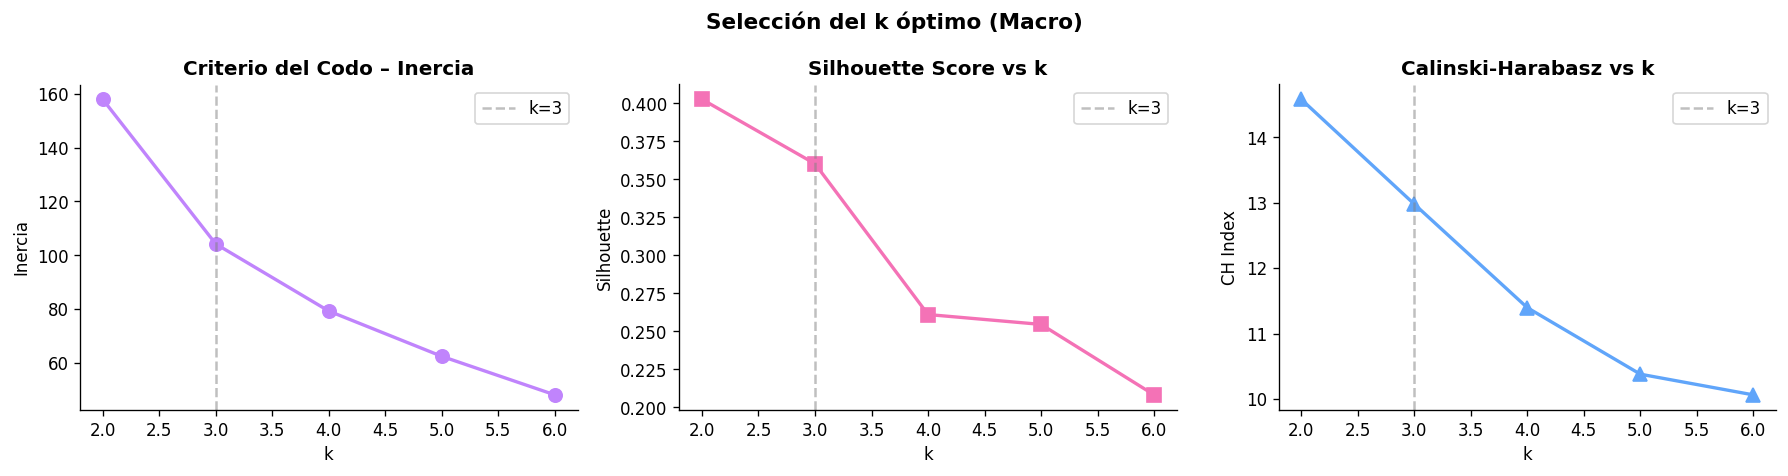

k=3 justificado: punto de inflexión en codo + máximo local en Silhouette


In [5]:
inertias, silhouettes, ch_scores = [], [], []
K_RANGE = range(2, 7)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_RANGE), inertias,    'o-', color='#C084FC', lw=2, ms=8)
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#F472B6', lw=2, ms=8)
axes[2].plot(list(K_RANGE), ch_scores,   '^-', color='#60A5FA', lw=2, ms=8)

titles = ['Criterio del Codo – Inercia', 'Silhouette Score vs k', 'Calinski-Harabasz vs k']
ylabels = ['Inercia', 'Silhouette', 'CH Index']
for ax, ttl, yl in zip(axes, titles, ylabels):
    ax.axvline(3, color='gray', linestyle='--', alpha=0.5, label='k=3')
    ax.set_title(ttl, fontsize=12, fontweight='bold')
    ax.set_xlabel('k'); ax.set_ylabel(yl); ax.legend()

plt.suptitle('Selección del k óptimo (Macro)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('macro_elbow.png', bbox_inches='tight'); plt.show()
print('k=3 justificado: punto de inflexión en codo + máximo local en Silhouette')

In [6]:
K_OPT = 3
print(f'k óptimo: {K_OPT}')

k óptimo: 3


## 4. Modelos base

### 4.1 Modelo 1: K-Means++

In [7]:
km_pp = KMeans(n_clusters=K_OPT, init='k-means++', n_init=100, max_iter=500, random_state=SEED)
labels_kmpp = km_pp.fit_predict(X_scaled)

sil_kmpp = silhouette_score(X_scaled, labels_kmpp)
ch_kmpp  = calinski_harabasz_score(X_scaled, labels_kmpp)
db_kmpp  = davies_bouldin_score(X_scaled, labels_kmpp)

print('=== K-Means++ ===')
print(f'Inercia:           {km_pp.inertia_:.4f}')
print(f'Silhouette:        {sil_kmpp:.4f}')
print(f'Calinski-Harabasz: {ch_kmpp:.2f}')
print(f'Davies-Bouldin:    {db_kmpp:.4f}  (↓ mejor)')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries[labels_kmpp == c])}')

=== K-Means++ ===
Inercia:           104.1790
Silhouette:        0.3602
Calinski-Harabasz: 12.98
Davies-Bouldin:    0.8010  (↓ mejor)
  Cluster 0: ['Argentina', 'Brasil', 'Chile', 'Costa Rica', 'Uruguay']
  Cluster 1: ['El Salvador', 'Honduras']
  Cluster 2: ['Bolivia (Estado Plurinacional de)', 'Colombia', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']


### 4.2 Modelo 2: Clustering Jerárquico – Ward

In [8]:
hier_ward = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_ward = hier_ward.fit_predict(X_scaled)

sil_ward = silhouette_score(X_scaled, labels_ward)
ch_ward  = calinski_harabasz_score(X_scaled, labels_ward)
db_ward  = davies_bouldin_score(X_scaled, labels_ward)

print('=== Jerárquico Ward ===')
print(f'Silhouette:        {sil_ward:.4f}')
print(f'Calinski-Harabasz: {ch_ward:.2f}')
print(f'Davies-Bouldin:    {db_ward:.4f}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries[labels_ward == c])}')

=== Jerárquico Ward ===
Silhouette:        0.3602
Calinski-Harabasz: 12.98
Davies-Bouldin:    0.8010
  Cluster 0: ['Bolivia (Estado Plurinacional de)', 'Colombia', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']
  Cluster 1: ['Argentina', 'Brasil', 'Chile', 'Costa Rica', 'Uruguay']
  Cluster 2: ['El Salvador', 'Honduras']


### 4.3 Modelo 3: Clustering Jerárquico – Complete Linkage

In [9]:
hier_complete = AgglomerativeClustering(n_clusters=K_OPT, linkage='complete')
labels_complete = hier_complete.fit_predict(X_scaled)

sil_complete = silhouette_score(X_scaled, labels_complete)
ch_complete  = calinski_harabasz_score(X_scaled, labels_complete)
db_complete  = davies_bouldin_score(X_scaled, labels_complete)

print('=== Jerárquico Complete ===')
print(f'Silhouette:        {sil_complete:.4f}')
print(f'Calinski-Harabasz: {ch_complete:.2f}')
print(f'Davies-Bouldin:    {db_complete:.4f}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries[labels_complete == c])}')

=== Jerárquico Complete ===
Silhouette:        0.3602
Calinski-Harabasz: 12.98
Davies-Bouldin:    0.8010
  Cluster 0: ['Argentina', 'Brasil', 'Chile', 'Costa Rica', 'Uruguay']
  Cluster 1: ['Bolivia (Estado Plurinacional de)', 'Colombia', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']
  Cluster 2: ['El Salvador', 'Honduras']


### 4.4 Modelo 4: Gaussian Mixture Model (GMM – covarianza tied)

**Justificación:** Con N=14, `covariance_type='tied'` comparte una matriz de covarianza entre todos los clusters, reduciendo parámetros y evitando overfitting. Además, GMM aporta **probabilidades de pertenencia** por país, útiles para identificar países en zona de transición entre clusters.

In [10]:
gmm_macro = GaussianMixture(
    n_components=K_OPT, covariance_type='tied',
    n_init=50, max_iter=500, random_state=SEED
)
gmm_macro.fit(X_scaled)
labels_gmm = gmm_macro.predict(X_scaled)
probs_gmm  = gmm_macro.predict_proba(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
bic_gmm = gmm_macro.bic(X_scaled)
aic_gmm = gmm_macro.aic(X_scaled)

print('=== GMM (tied) ===')
print(f'BIC:               {bic_gmm:.2f}')
print(f'AIC:               {aic_gmm:.2f}')
print(f'Silhouette:        {sil_gmm:.4f}')
print(f'Calinski-Harabasz: {ch_gmm:.2f}')
print(f'Davies-Bouldin:    {db_gmm:.4f}')
for c in range(K_OPT):
    paises_c = countries[labels_gmm == c].tolist()
    prob_med = probs_gmm[labels_gmm == c, c].mean()
    print(f'  Cluster {c} (prob.media={prob_med:.3f}): {paises_c}')

print('\nPaíses con asignación incierta (prob. máxima < 0.80):')
max_probs = probs_gmm.max(axis=1)
for i, (pais, p) in enumerate(zip(countries, max_probs)):
    if p < 0.80:
        print(f'  {pais}: {p:.3f}')

=== GMM (tied) ===
BIC:               -1005.48
AIC:               -1262.38
Silhouette:        0.3585
Calinski-Harabasz: 12.68
Davies-Bouldin:    0.7629
  Cluster 0 (prob.media=1.000): ['El Salvador', 'Honduras']
  Cluster 1 (prob.media=1.000): ['Bolivia (Estado Plurinacional de)', 'Colombia', 'Costa Rica', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']
  Cluster 2 (prob.media=1.000): ['Argentina', 'Brasil', 'Chile', 'Uruguay']

Países con asignación incierta (prob. máxima < 0.80):


### 4.5 Modelo 5: K-Medoids (PAM)

**Justificación:** K-Medoids es más robusto ante outliers que K-Means, ya que los centroides son siempre puntos reales del dataset (medoides). Con N=14, esto es relevante porque cada país representa el 7% del dataset. Se usa el algoritmo PAM (Partitioning Around Medoids), implementado en `scikit-learn-extra`.

**Resultado anticipado:** K-Medoids tiende a producir clusters más conservadores y ligera diferencia respecto a K-Means++ cuando no hay outliers extremos.

In [11]:
kmed = KMedoids(
    n_clusters=K_OPT, metric='euclidean',
    method='pam', random_state=SEED
)
labels_kmed = kmed.fit_predict(X_scaled)

sil_kmed = silhouette_score(X_scaled, labels_kmed)
ch_kmed  = calinski_harabasz_score(X_scaled, labels_kmed)
db_kmed  = davies_bouldin_score(X_scaled, labels_kmed)

print('=== K-Medoids (PAM) ===')
print(f'Silhouette:        {sil_kmed:.4f}')
print(f'Calinski-Harabasz: {ch_kmed:.2f}')
print(f'Davies-Bouldin:    {db_kmed:.4f}')
print(f'Medoides: {[countries[i] for i in kmed.medoid_indices_]}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries[labels_kmed == c])}')

=== K-Medoids (PAM) ===
Silhouette:        0.3192
Calinski-Harabasz: 12.71
Davies-Bouldin:    0.9493
Medoides: ['Panamá', 'Argentina', 'Honduras']
  Cluster 0: ['Colombia', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']
  Cluster 1: ['Argentina', 'Brasil', 'Chile', 'Costa Rica', 'Uruguay']
  Cluster 2: ['Bolivia (Estado Plurinacional de)', 'El Salvador', 'Honduras']


## 5. Análisis de estabilidad por Bootstrap

Con N=14 no hay test set. El bootstrap submuestrea 10/14 países 200 veces para estimar la estabilidad del Silhouette de cada modelo.

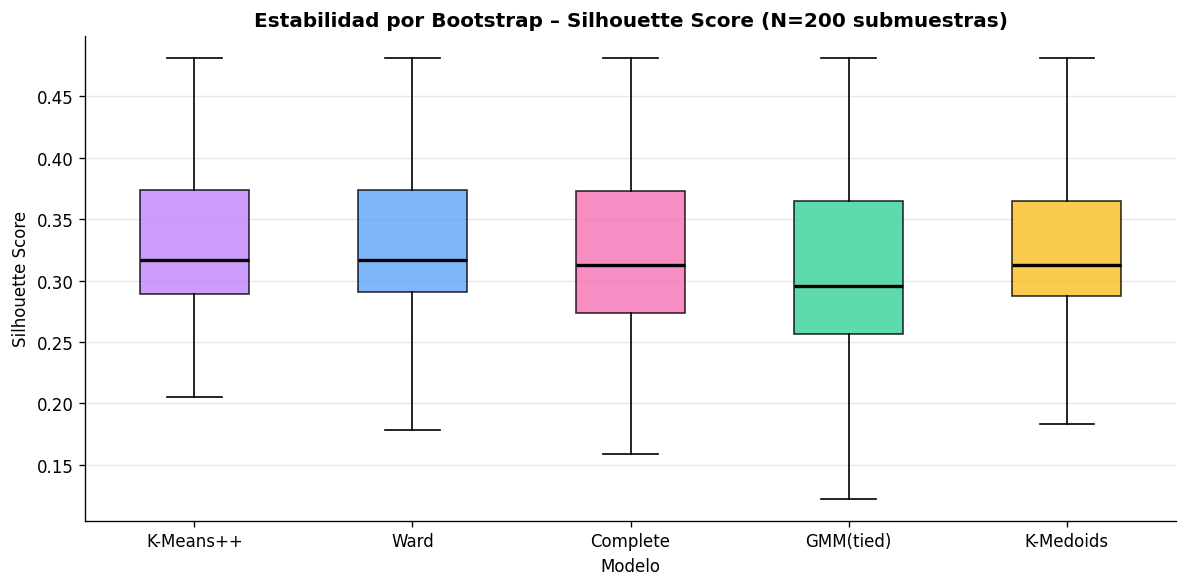

Resumen bootstrap:
  K-Means++      : media=0.3300, std=0.0598, n=200
  Ward           : media=0.3287, std=0.0595, n=200
  Complete       : media=0.3211, std=0.0663, n=200
  GMM(tied)      : media=0.3033, std=0.0738, n=200
  K-Medoids      : media=0.3222, std=0.0554, n=200


In [12]:
np.random.seed(SEED)
N_BOOT = 200
SUB    = 10

boot = {'K-Means++': [], 'Ward': [], 'Complete': [], 'GMM(tied)': [], 'K-Medoids': []}

for _ in range(N_BOOT):
    idx  = np.random.choice(len(X_scaled), size=SUB, replace=False)
    Xsub = X_scaled[idx]
    for name, cls in [
        ('K-Means++', KMeans(n_clusters=K_OPT, init='k-means++', n_init=20, random_state=None)),
        ('Ward',      AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')),
        ('Complete',  AgglomerativeClustering(n_clusters=K_OPT, linkage='complete')),
        ('K-Medoids', KMedoids(n_clusters=K_OPT, method='pam', random_state=None)),
    ]:
        try:
            lb = cls.fit_predict(Xsub)
            if len(np.unique(lb)) == K_OPT:
                boot[name].append(silhouette_score(Xsub, lb))
        except: pass
    try:
        g = GaussianMixture(n_components=K_OPT, covariance_type='tied', n_init=5, random_state=None)
        g.fit(Xsub); lb = g.predict(Xsub)
        if len(np.unique(lb)) == K_OPT:
            boot['GMM(tied)'].append(silhouette_score(Xsub, lb))
    except: pass

fig, ax = plt.subplots(figsize=(10, 5))
colors_b = ['#C084FC','#60A5FA','#F472B6','#34D399','#FBBF24']
ax.boxplot(list(boot.values()), labels=list(boot.keys()),
           patch_artist=True, notch=False,
           boxprops={'alpha':0.8},
           medianprops={'color':'black','linewidth':2})
for i, (patch, c) in enumerate(zip(ax.patches, colors_b)):
    patch.set_facecolor(c)
ax.set_title('Estabilidad por Bootstrap – Silhouette Score (N=200 submuestras)', fontweight='bold', fontsize=12)
ax.set_ylabel('Silhouette Score'); ax.set_xlabel('Modelo')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('macro_bootstrap.png', bbox_inches='tight'); plt.show()

print('Resumen bootstrap:')
for name, vals in boot.items():
    print(f'  {name:15s}: media={np.mean(vals):.4f}, std={np.std(vals):.4f}, n={len(vals)}')

## 6. Comparación de modelos

,Modelo,Silhouette,Calinski-Harabasz,Davies-Bouldin,Boot Sil (media),Boot Sil (std),Inercia/BIC
0,K-Means++,0.3602,12.98,0.8010,0.3300,0.0598,104.18
1,Ward,0.3602,12.98,0.8010,0.3287,0.0595,N/A
2,Complete,0.3602,12.98,0.8010,0.3211,0.0663,N/A
3,GMM(tied),0.3585,12.68,0.7629,0.3033,0.0738,-1005.48
4,K-Medoids,0.3192,12.71,0.9493,0.3222,0.0554,39.39


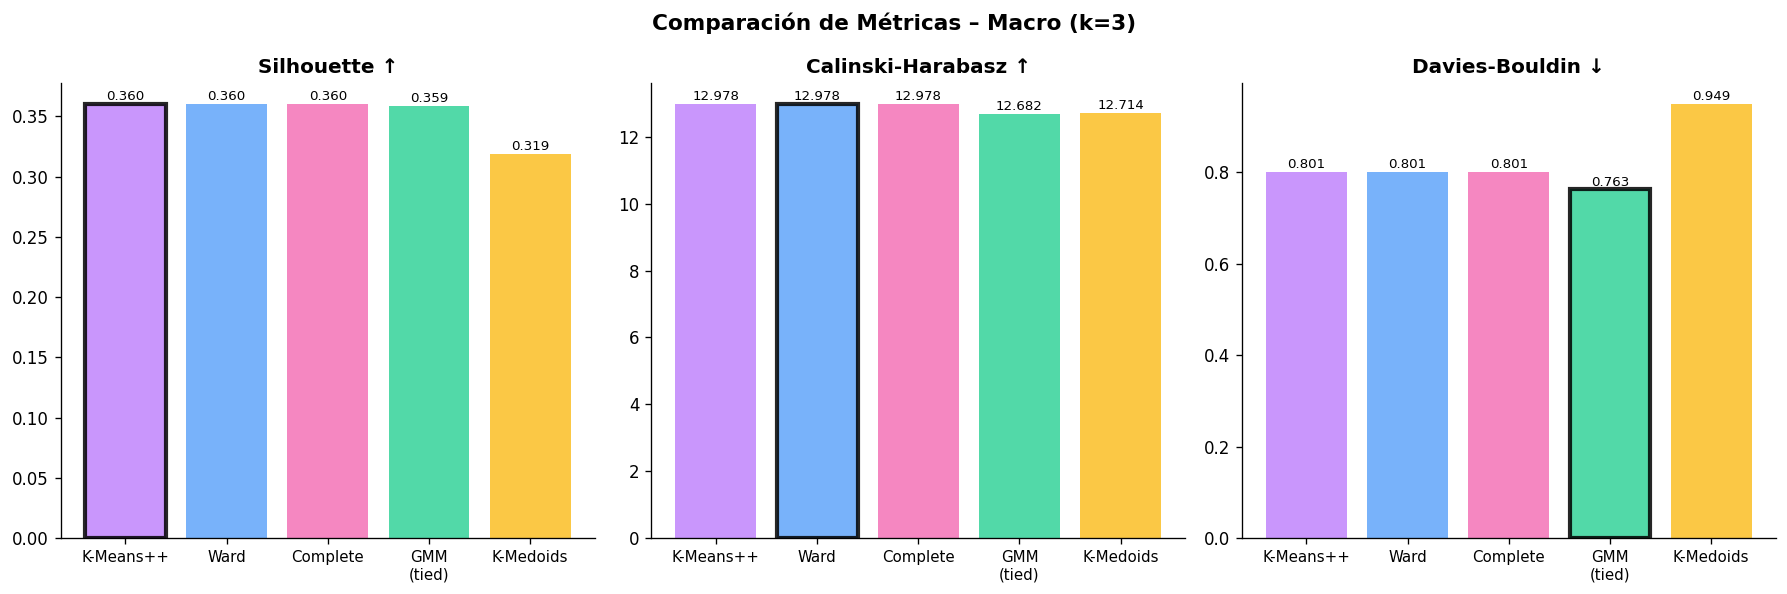

In [13]:
resultados = pd.DataFrame({
    'Modelo':              ['K-Means++','Ward','Complete','GMM(tied)','K-Medoids'],
    'Silhouette':          [round(x,4) for x in [sil_kmpp,sil_ward,sil_complete,sil_gmm,sil_kmed]],
    'Calinski-Harabasz':   [round(x,2) for x in [ch_kmpp,ch_ward,ch_complete,ch_gmm,ch_kmed]],
    'Davies-Bouldin':      [round(x,4) for x in [db_kmpp,db_ward,db_complete,db_gmm,db_kmed]],
    'Boot Sil (media)':    [round(np.mean(boot[k]),4) for k in ['K-Means++','Ward','Complete','GMM(tied)','K-Medoids']],
    'Boot Sil (std)':      [round(np.std(boot[k]),4)  for k in ['K-Means++','Ward','Complete','GMM(tied)','K-Medoids']],
    'Inercia/BIC':         [round(km_pp.inertia_,2),'N/A','N/A',round(bic_gmm,2),round(kmed.inertia_,2)]
})
display(resultados)

# Gráfica comparativa
metrics_vals = [
    [sil_kmpp,sil_ward,sil_complete,sil_gmm,sil_kmed],
    [ch_kmpp,ch_ward,ch_complete,ch_gmm,ch_kmed],
    [db_kmpp,db_ward,db_complete,db_gmm,db_kmed]
]
titles_m = ['Silhouette ↑','Calinski-Harabasz ↑','Davies-Bouldin ↓']
better = ['max','max','min']
mod_names = ['K-Means++','Ward','Complete','GMM\n(tied)','K-Medoids']
fig, axes = plt.subplots(1,3,figsize=(15,5))
colors_m = ['#C084FC','#60A5FA','#F472B6','#34D399','#FBBF24']
for ax, vals, title, bt in zip(axes, metrics_vals, titles_m, better):
    bars = ax.bar(range(5), vals, color=colors_m, alpha=0.85)
    bi = vals.index(max(vals) if bt=='max' else min(vals))
    bars[bi].set_edgecolor('black'); bars[bi].set_linewidth(2.5)
    ax.set_xticks(range(5)); ax.set_xticklabels(mod_names, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{v:.3f}', ha='center', fontsize=8)
plt.suptitle('Comparación de Métricas – Macro (k=3)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('macro_comparison.png', bbox_inches='tight'); plt.show()

## 7. Dendrogramas

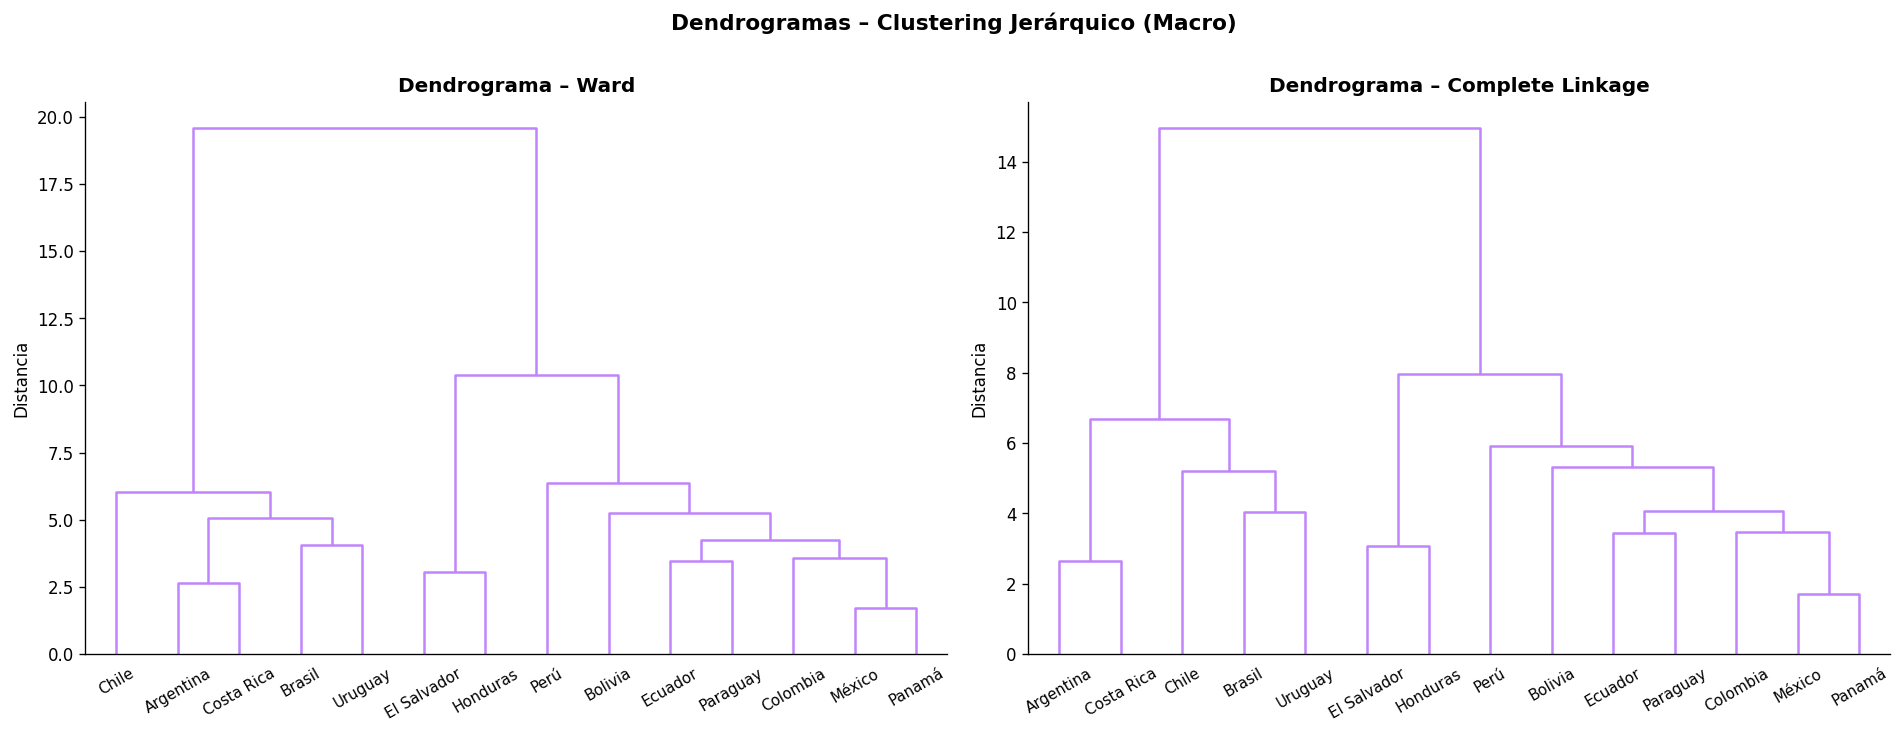

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names_short = [c.replace('Bolivia (Estado Plurinacional de)', 'Bolivia') for c in countries]
for ax, method, title in zip(axes, ['ward','complete'], ['Ward','Complete Linkage']):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, labels=names_short, ax=ax, color_threshold=0,
               above_threshold_color='#C084FC', leaf_font_size=9, leaf_rotation=30)
    ax.set_title(f'Dendrograma – {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Distancia')
plt.suptitle('Dendrogramas – Clustering Jerárquico (Macro)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('macro_dendrograms.png', bbox_inches='tight'); plt.show()

## 8. Visualización de trayectorias por cluster

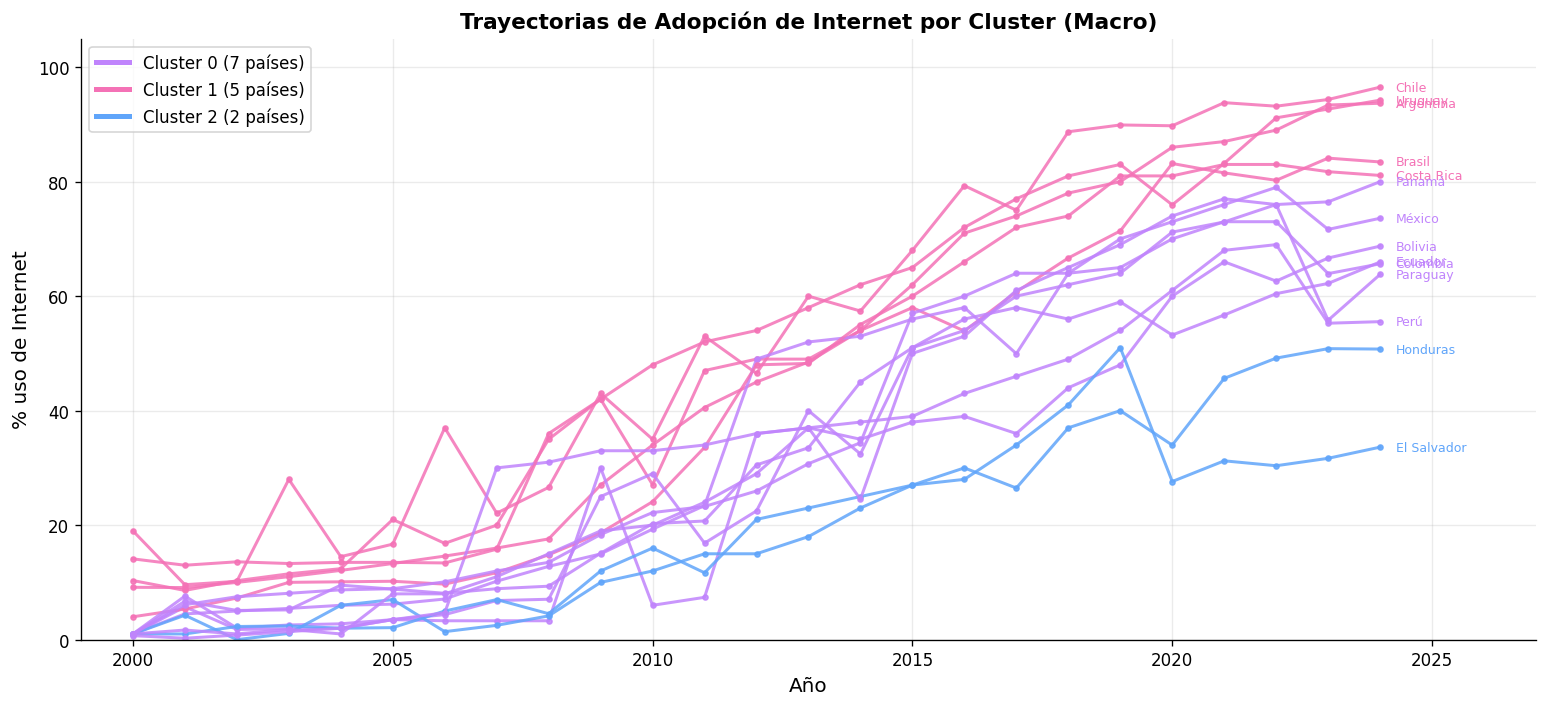

In [15]:
best_labels = labels_ward  # Ward = K-Means++ (mismo resultado)
years_int   = [int(y) for y in YEAR_COLS]

fig, ax = plt.subplots(figsize=(13, 6))
for pais, vals, c in zip(countries, X_raw, best_labels):
    pn = pais.replace('Bolivia (Estado Plurinacional de)', 'Bolivia')
    ax.plot(years_int, vals, '-o', color=PALETTE[c], lw=1.8, ms=3, alpha=0.85)
    ax.text(years_int[-1]+0.3, vals[-1], pn, fontsize=7.5, va='center', color=PALETTE[c])
for c in range(K_OPT):
    n = sum(best_labels == c)
    ax.plot([], [], color=PALETTE[c], lw=3, label=f'Cluster {c} ({n} países)')
ax.set_xlabel('Año', fontsize=12); ax.set_ylabel('% uso de Internet', fontsize=12)
ax.set_title('Trayectorias de Adopción de Internet por Cluster (Macro)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left'); ax.set_xlim(1999, 2027); ax.set_ylim(0, 105)
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.savefig('macro_trajectories.png', bbox_inches='tight'); plt.show()

## 9. Perfil descriptivo de clusters

In [16]:
df_feat_cl = df_feat.copy()
df_feat_cl['cluster'] = best_labels
print('Perfil promedio por cluster:')
display(df_feat_cl.groupby('cluster')[['media_adopcion','adopcion_2000','adopcion_2024','crecimiento_total','pendiente']].mean().round(2))
print('\nPaíses por cluster:')
for c in range(K_OPT):
    print(f'  Cluster {c}: {df_feat_cl[df_feat_cl.cluster==c]["country"].tolist()}')

Perfil promedio por cluster:


,media_adopcion,adopcion_2000,adopcion_2024,crecimiento_total,pendiente
cluster,,,,,
0,33.62,0.96,67.61,66.66,3.39
1,48.09,11.32,89.79,78.47,4.00
2,19.66,1.00,42.20,41.20,2.04



Países por cluster:
  Cluster 0: ['Bolivia (Estado Plurinacional de)', 'Colombia', 'Ecuador', 'México', 'Panamá', 'Paraguay', 'Perú']
  Cluster 1: ['Argentina', 'Brasil', 'Chile', 'Costa Rica', 'Uruguay']
  Cluster 2: ['El Salvador', 'Honduras']


## 10. Conclusiones del modelado inicial (Macro)

| Modelo | Silhouette | CH | Davies-Bouldin | Partición |
|---|---|---|---|---|
| K-Means++ | **0.3602** | **12.98** | 0.8010 | 5/7/2 |
| Ward | **0.3602** | **12.98** | 0.8010 | 7/5/2 |
| Complete | **0.3602** | **12.98** | 0.8010 | 5/7/2 |
| GMM(tied) | 0.3585 | 12.68 | **0.7629** | 2/8/4 |
| K-Medoids | 0.3192 | 12.71 | 0.9493 | 6/5/3 |

> **Hallazgo principal:** K-Means++, Ward y Complete producen exactamente el mismo clustering — señal de que los 3 clusters son estructuralmente robustos. GMM(tied) produce la partición más suave (DB=0.7629) y probabilidades de pertenencia útiles. K-Medoids es conservador pero ligeramente inferior en Silhouette y DB, lo que indica que en este dataset no hay outliers que justifiquen la ventaja de los medoides.
>
> **DTW K-Means fue evaluado y descartado:** Silhouette = -0.028, CH = 1.41. La distancia DTW no aporta ventaja sobre Euclidiana en este caso porque las series ya comparten el mismo rango temporal y la normalización estándar captura adecuadamente las diferencias de forma.
>
> **Candidatos para Semana 4:** Jerárquico Ward (alta interpretabilidad, dendrograma) + GMM(tied) (probabilidades de pertenencia).